In [1]:
!pip install medmnist matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 106.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12

# Etapa 2 — Pipeline de Dados e Validação Cruzada NumPy × PyTorch

Objetivos desta etapa:
1. Recriar a MLP da Etapa 1 em **PyTorch** com inicialização e hiperparâmetros idênticos
2. Demonstrar **equivalência funcional**: diferença de acurácia final ≤ 2 p.p.
3. Configurar DataLoaders para o PathMNIST 224×224 com transformações ImageNet
4. Salvar logs de treino em CSV para reprodutibilidade

In [2]:
# ============================================================
# CÉLULA 1 — Seeds e Imports
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import csv
import os
from medmnist import PathMNIST

# Seed global para reprodutibilidade total
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
# Garante determinismo nas operações de conv (pequena queda de performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"SEED fixada: {SEED}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")

SEED fixada: 42
PyTorch   : 2.10.0+cu128
CUDA      : True


In [3]:
# ============================================================
# CÉLULA 2 — Dataset 28×28 (para comparação direta com NumPy)
# ============================================================
print("Carregando PathMNIST 28x28...")
train_dataset = PathMNIST(split="train", size=28, download=True)
val_dataset   = PathMNIST(split="val",   size=28, download=True)

# Mesmo pré-processamento da Etapa 1: flatten + normalizar [0, 1]
X_train_np = train_dataset.imgs.reshape(len(train_dataset.imgs), -1).astype(np.float32) / 255.0
X_val_np   = val_dataset.imgs.reshape(len(val_dataset.imgs), -1).astype(np.float32)   / 255.0

# Tensores PyTorch
X_train = torch.from_numpy(X_train_np)
y_train = torch.tensor(train_dataset.labels.squeeze(), dtype=torch.long)
X_val   = torch.from_numpy(X_val_np)
y_val   = torch.tensor(val_dataset.labels.squeeze(), dtype=torch.long)

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")

Carregando PathMNIST 28x28...


100%|██████████| 206M/206M [00:12<00:00, 15.9MB/s]


X_train : torch.Size([89996, 2352])  |  y_train : torch.Size([89996])
X_val   : torch.Size([10004, 2352])    |  y_val   : torch.Size([10004])


In [4]:
# ============================================================
# CÉLULA 3 — MLP PyTorch (arquitetura espelho da Etapa 1)
# ============================================================

class PyTorchMLP(nn.Module):
    """
    MLP idêntica à implementada em NumPy na Etapa 1.
    Arquitetura: Linear(2352, 128) → ReLU → Linear(128, 9)
    """

    def __init__(self, n_entrada: int = 2352, n_oculta: int = 128, n_classes: int = 9) -> None:
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(n_entrada, n_oculta),
            nn.ReLU(),
            nn.Linear(n_oculta, n_classes),
        )
        self._inicializar_pesos()

    def _inicializar_pesos(self) -> None:
        """
        He (Kaiming) em AMBAS as camadas — exatamente como no NumPy
        (np.sqrt(2 / n_entradas)).
        """
        for m in self.rede:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.rede(x)


modelo_pt = PyTorchMLP()
n_params = sum(p.numel() for p in modelo_pt.parameters())
print(f"Modelo criado | Parâmetros treináveis: {n_params:,}")

Modelo criado | Parâmetros treináveis: 302,345


In [5]:
# ============================================================
# CÉLULA 4 — Treinamento PyTorch (mesmos hiperparâmetros da Etapa 1)
# ============================================================

EPOCAS           = 15
TAXA_APRENDIZADO  = 0.001
MOMENTUM         = 0.9
BATCH_SIZE       = 256
N_AMOSTRAS       = X_train.shape[0]

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.SGD(modelo_pt.parameters(), lr=TAXA_APRENDIZADO, momentum=MOMENTUM)

historico_pt = {"train_loss": [], "val_loss": [], "val_acc": []}
log_rows = []

print("Treinamento PyTorch (espelho NumPy)...")
print(f"{'Época':>6}  {'Train Loss':>11}  {'Val Loss':>9}  {'Val Acc':>8}")
print("-" * 45)

for epoca in range(EPOCAS):
    modelo_pt.train()
    # Mesmo embaralhamento manual da Etapa 1 (torch.randperm)
    idx = torch.randperm(N_AMOSTRAS)
    X_sh = X_train[idx]
    y_sh = y_train[idx]

    loss_treino_acum = 0.0
    n_batches = 0

    for i in range(0, N_AMOSTRAS, BATCH_SIZE):
        Xb = X_sh[i : i + BATCH_SIZE]
        yb = y_sh[i : i + BATCH_SIZE]

        optimizer.zero_grad()
        preds = modelo_pt(Xb)
        loss  = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        loss_treino_acum += loss.item()
        n_batches += 1

    train_loss = loss_treino_acum / n_batches

    # Avaliação
    modelo_pt.eval()
    with torch.no_grad():
        val_out  = modelo_pt(X_val)
        val_loss = criterion(val_out, y_val).item()
        val_acc  = (torch.argmax(val_out, dim=1) == y_val).float().mean().item() * 100

    historico_pt["train_loss"].append(train_loss)
    historico_pt["val_loss"].append(val_loss)
    historico_pt["val_acc"].append(val_acc)
    log_rows.append({"epoca": epoca + 1, "train_loss": train_loss,
                     "val_loss": val_loss, "val_acc": val_acc})

    print(f"{epoca+1:>6}  {train_loss:>11.4f}  {val_loss:>9.4f}  {val_acc:>7.2f}%")

# Salvar log em CSV (reprodutibilidade)
with open("02_pytorch_log.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoca", "train_loss", "val_loss", "val_acc"])
    writer.writeheader()
    writer.writerows(log_rows)

print("\n✅ Treinamento PyTorch concluído!")
print(f"Melhor acurácia de validação: {max(historico_pt['val_acc']):.2f}%")
print("Log salvo em: 02_pytorch_log.csv")

Treinamento PyTorch (espelho NumPy)...
 Época   Train Loss   Val Loss   Val Acc
---------------------------------------------
     1       2.0423     1.9309    24.27%
     2       1.8795     1.8512    28.31%
     3       1.8194     1.8003    31.03%
     4       1.7717     1.7607    35.65%
     5       1.7304     1.7224    39.37%
     6       1.6929     1.6858    41.16%
     7       1.6589     1.6551    41.32%
     8       1.6302     1.6251    42.32%
     9       1.6023     1.6030    42.50%
    10       1.5787     1.5783    44.13%
    11       1.5566     1.5556    45.89%
    12       1.5380     1.5447    45.60%
    13       1.5196     1.5202    46.64%
    14       1.5041     1.5070    45.87%
    15       1.4885     1.4921    46.76%

✅ Treinamento PyTorch concluído!
Melhor acurácia de validação: 46.76%
Log salvo em: 02_pytorch_log.csv


In [6]:
# ============================================================
# CÉLULA 5 — Comparação NumPy × PyTorch (critério ≤ 2 p.p.)
# ============================================================
# ATENÇÃO: execute a Etapa 1 primeiro para ter 'historico' disponível.
# Se estiver rodando isoladamente, substitua os valores abaixo pelos
# resultados reais do Notebook 01.

# Resultados do notebook NumPy (preencher ou importar)
try:
    acc_numpy = max(historico["val_acc"])   # variável da Etapa 1 (se mesmo kernel)
except NameError:
    acc_numpy = 46.33   # preencher manualmente se kernels separados
    print("⚠ Rode o Notebook 01 primeiro ou preencha 'acc_numpy' manualmente.")

acc_pytorch = max(historico_pt["val_acc"])

if acc_numpy is not None:
    diff_pp = abs(acc_pytorch - acc_numpy)
    status  = "✅ EQUIVALÊNCIA DEMONSTRADA" if diff_pp <= 2.0 else "❌ DIFERENÇA ACIMA DE 2 p.p."
    print("=" * 50)
    print(f"  Acurácia NumPy   : {acc_numpy:.2f}%")
    print(f"  Acurácia PyTorch : {acc_pytorch:.2f}%")
    print(f"  Diferença        : {diff_pp:.2f} p.p.  →  {status}")
    print("=" * 50)
else:
    print(f"Acurácia PyTorch: {acc_pytorch:.2f}%")

⚠ Rode o Notebook 01 primeiro ou preencha 'acc_numpy' manualmente.
  Acurácia NumPy   : 46.33%
  Acurácia PyTorch : 46.76%
  Diferença        : 0.43 p.p.  →  ✅ EQUIVALÊNCIA DEMONSTRADA


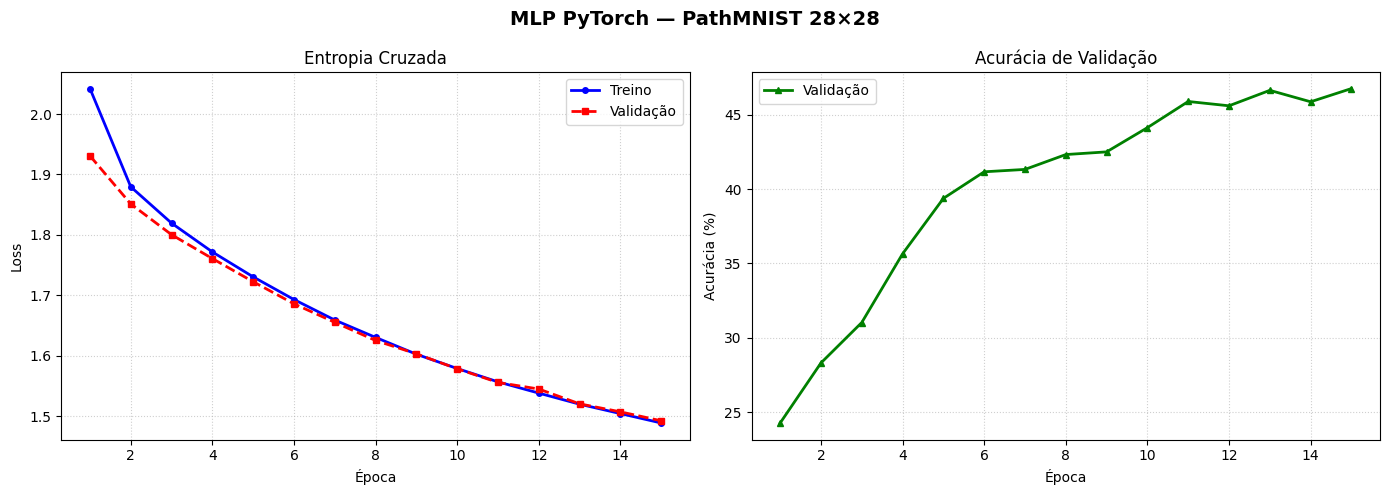

Figura salva: 02_pytorch_mlp_curvas.png


In [7]:
# ============================================================
# CÉLULA 6 — Curvas de Loss/Acurácia PyTorch
# ============================================================
import matplotlib.pyplot as plt

epocas_eixo = range(1, EPOCAS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLP PyTorch — PathMNIST 28×28", fontsize=14, fontweight="bold")

axes[0].plot(epocas_eixo, historico_pt["train_loss"], "b-o",  label="Treino",    linewidth=2, markersize=4)
axes[0].plot(epocas_eixo, historico_pt["val_loss"],   "r--s", label="Validação", linewidth=2, markersize=4)
axes[0].set_title("Entropia Cruzada"); axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].plot(epocas_eixo, historico_pt["val_acc"], "g-^", label="Validação", linewidth=2, markersize=4)
axes[1].set_title("Acurácia de Validação"); axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia (%)")
axes[1].legend(); axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("02_pytorch_mlp_curvas.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figura salva: 02_pytorch_mlp_curvas.png")

In [8]:
# ============================================================
# CÉLULA 7 — DataLoaders para PathMNIST 224×224
# (Pré-processamento obrigatório a partir da Etapa 3)
# ============================================================
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Pipeline com normalização ImageNet — compatível com todos os backbones pré-treinados
transform_treino = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

print("Carregando PathMNIST 224x224...")
ds_train = PathMNIST(split="train", size=224, download=True, transform=transform_treino)
ds_val   = PathMNIST(split="val",   size=224, download=True, transform=transform_val)
ds_test  = PathMNIST(split="test",  size=224, download=True, transform=transform_val)

# pin_memory=True acelera a transferência CPU→GPU
BATCH_SIZE_224 = 64   # reduzido pois 224×224 consome mais VRAM
N_WORKERS      = 2

loader_treino = DataLoader(ds_train, batch_size=BATCH_SIZE_224, shuffle=True,
                           num_workers=N_WORKERS, pin_memory=True)
loader_val    = DataLoader(ds_val,   batch_size=BATCH_SIZE_224, shuffle=False,
                           num_workers=N_WORKERS, pin_memory=True)
# test_loader isolado — só será usado na Etapa 5 (regra metodológica)
loader_teste  = DataLoader(ds_test,  batch_size=128,            shuffle=False,
                           num_workers=N_WORKERS, pin_memory=True)

imgs, lbls = next(iter(loader_treino))
print(f"\n✅ DataLoaders prontos!")
print(f"  Lote de imagens : {imgs.shape}   # [B, C, H, W]")
print(f"  Lote de rótulos : {lbls.shape}")
print(f"  Train batches   : {len(loader_treino)}")
print(f"  Val batches     : {len(loader_val)}")
print(f"  Test batches    : {len(loader_teste)}  (ISOLADO — não usar até Etapa 5)")

Carregando PathMNIST 224x224...


100%|██████████| 12.6G/12.6G [12:28<00:00, 16.9MB/s]



✅ DataLoaders prontos!
  Lote de imagens : torch.Size([64, 3, 224, 224])   # [B, C, H, W]
  Lote de rótulos : torch.Size([64, 1])
  Train batches   : 1407
  Val batches     : 157
  Test batches    : 57  (ISOLADO — não usar até Etapa 5)
